In [60]:
#imports

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from schnell.mapping import MapCalculator
from schnell.detector import LISADetector

In [61]:
#constanten enzo

C_LIGHT = 299_792_458.0
L_ARM   = 2.5e9
F_STAR  = C_LIGHT / (2.0 * np.pi * L_ARM)

MPC_M     = 3.0856775814913673e22
H0_OVER_h = (100.0 * 1000.0) / MPC_M  

P_OMS_PM = 15.0  
A_ACC_FM = 3.0  

In [62]:
#funties vanuit appendix B; N_TT tilde en N_AE tilde

def S_oms(f):
    f = np.asarray(f, dtype=float)
    return (P_OMS_PM * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc(f):
    f = np.asarray(f, dtype=float)
    return (A_ACC_FM * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE(f):
    f = np.asarray(f, dtype=float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = 0.5 * (2.0 + cosx) * (S_oms(f) / (L_ARM**2))
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc(f) / (L_ARM**2)) * (1.0 / (2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T(f):
    f = np.asarray(f, dtype=float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = (1.0 - cosx) * (S_oms(f) / (L_ARM**2))
    term_acc = 2.0 * (1.0 - cosx)**2 * (S_acc(f) / (L_ARM**2)) * (1.0 / (2.0*np.pi*f))**4
    return term_oms + term_acc


In [63]:
def map2alm_complex(hp_map, lmax, iter=20):
    hp_map = np.asarray(hp_map)
    alm_re = hp.map2alm(np.real(hp_map), lmax=lmax, iter=iter, use_weights=True)
    alm_im = hp.map2alm(np.imag(hp_map), lmax=lmax, iter=iter, use_weights=True)
    return alm_re + 1j * alm_im

In [64]:
C_AET = np.array([
    [-1/np.sqrt(2),  0.0,          1/np.sqrt(2)],   # A
    [ 1/np.sqrt(6), -2/np.sqrt(6), 1/np.sqrt(6)],   # E
    [ 1/np.sqrt(3),  1/np.sqrt(3), 1/np.sqrt(3)],   # T  Dit is Eq. 4.25, de andere verglijkingen werkte niet. Dus we doen het via DeltaF
    ], dtype=float)

OIDX = {"A": 0, "E": 1, "T": 2}


def Rlm_OOp_from_rlmij(mat_ij, O, Op):
    cO  = C_AET[OIDX[O]]
    cOp = C_AET[OIDX[Op]]
    return np.sum(cO[:, None] * cOp[None, :] * mat_ij) # dit is eq. 4.27 in de paper
    
def Rell_OOp_from_rlmij_fullm(rlm_ij_by_m, ell, O, Op): 
    s = 0.0
    for m in range(-ell, ell + 1):
        zm = Rlm_OOp_from_rlmij(rlm_ij_by_m[m], O, Op)
        s += np.abs(zm)**2
    return np.sqrt(s)

In [105]:
import numpy as np

def Rell_OOp_analytical(rlm_ij_by_m, ell, O, Op):
    """
    Computes the analytical channel combinations using Eqs 4.29 and 4.30 
    from Bartolo et al. (2022).
    
    Parameters:
    - rlm_ij_by_m: dictionary mapping `m` to the 3x3 complex numpy array of responses.
                   (rlm_ij_by_m[m][0, 0] is R_11, rlm_ij_by_m[m][0, 1] is R_12)
    - ell: the multipole (int)
    - O, Op: channel string names (e.g., 'A', 'E', 'T')
    """
    # Sort the pair to handle symmetry (e.g., 'EA' -> 'AE')
    pair = "".join(sorted([O, Op]))
    
    val_sq = 0.0
    
    # ==========================================
    # ODD MULTIPOLES (Equation 4.29)
    # ==========================================
    if ell % 2 != 0:
        if pair in ["AA", "EE", "TT"]:
            return 0.0
        
        for m in range(-ell, ell + 1):
            # For odd l, we only need R_12
            R12 = rlm_ij_by_m[m][0, 1]
            
            if pair == "AE":
                coeff = np.abs(1.0 + 2.0 * np.cos(2.0 * m * np.pi / 3.0))**2
                val_sq += (1.0 / 3.0) * coeff * np.abs(R12)**2
            
            elif pair in ["AT", "ET"]:
                coeff = np.sin(m * np.pi / 3.0)**2
                val_sq += 2.0 * coeff * np.abs(R12)**2

    # ==========================================
    # EVEN MULTIPOLES (Equation 4.30)
    # ==========================================
    else:
        for m in range(-ell, ell + 1):
            # For even l, we need both R_11 and R_12
            R11 = rlm_ij_by_m[m][0, 0]
            R12 = rlm_ij_by_m[m][0, 1]
            
            if pair in ["AA", "EE"]:
                phase_term = 1.0 + np.exp(-4.0/3.0 * 1j * m * np.pi)
                term = phase_term * R11 - 2.0 * R12
                val_sq += (1.0 / 4.0) * np.abs(term)**2
                
            elif pair == "TT":
                coeff = (1.0 + 2.0 * np.cos(2.0 * m * np.pi / 3.0))**2
                term = R11 + 2.0 * R12
                val_sq += (1.0 / 9.0) * coeff * np.abs(term)**2
                
            elif pair == "AE":
                coeff = np.sin(m * np.pi / 3.0)**2
                phase_term = 1.0 + np.exp(2.0/3.0 * 1j * m * np.pi)
                term = phase_term * R11 - 2.0 * R12
                val_sq += (1.0 / 3.0) * coeff * np.abs(term)**2
                
            elif pair in ["AT", "ET"]:
                coeff = np.sin(m * np.pi / 3.0)**2
                phase_term = 1.0 + np.exp(2.0/3.0 * 1j * m * np.pi)
                term = phase_term * R11 + R12
                val_sq += (2.0 / 3.0) * coeff * np.abs(term)**2

    # Eq 4.28 specifies taking the square root of the sum
    return np.sqrt(val_sq)

In [116]:
def compute_Rlm_ij(f_grid, lmax, nside, t0=0.0, iter=10, use_weights=True):
    f_grid = np.asarray(f_grid, dtype=float)

    dets = [LISADetector(detector_id=i) for i in range(3)]
    mc = MapCalculator(dets)

    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    lmax_alm = min(3*nside - 1, max(lmax, 4*lmax))  # internal lmax to reduce leakage

    def antenna_alm(i, j, f):
        ant = mc.get_antenna(i, j, t0, float(f), theta, phi, pol=False, inc_baseline=True)
        ant = np.asarray(ant).squeeze()
        if ant.shape != (npix,):
            raise RuntimeError(f"get_antenna returned {ant.shape} (expected {(npix,)}) dtype {ant.dtype}")
    
        lmax_out = int(lmax)  # explicit
        lmax_full = int(lmax_alm)
    
        alm_full = map2alm_complex(
            ant, lmax_full, iter
        )
    
        # sizes
        size_out = hp.Alm.getsize(lmax_out)
        size_full = hp.Alm.getsize(lmax_full)
        if alm_full.shape[0] != size_full:
            raise RuntimeError(f"alm_full has size {alm_full.shape[0]} but expected {size_full} for lmax_full={lmax_full}")
    
        alm_out = np.zeros(size_out, dtype=np.complex128)
    
        # truncate safely
        for ell in range(lmax_out + 1):
            for m in range(ell + 1):
                idx_full = hp.Alm.getidx(lmax_full, ell, m)
                idx_out  = hp.Alm.getidx(lmax_out,  ell, m)
    
                if idx_out >= size_out:
                    raise RuntimeError(f"idx_out={idx_out} >= size_out={size_out} (lmax_out={lmax_out}, ell={ell}, m={m})")
                if idx_full >= size_full:
                    raise RuntimeError(f"idx_full={idx_full} >= size_full={size_full} (lmax_full={lmax_full}, ell={ell}, m={m})")
    
                alm_out[idx_out] = alm_full[idx_full]
    
        return alm_out
    rlm_all = []
    for f in f_grid:
        M = [[None]*3 for _ in range(3)]
        for i in range(3):
            for j in range(3):
                M[i][j] = antenna_alm(i, j, f)
        rlm_all.append(M)

    return rlm_all

In [117]:
def omega_from_pair_threshold(f_grid, Rv, N1, N2, rel_thr=1e-7, abs_thr=0.0):
    f_grid = np.asarray(f_grid, dtype=float)
    Rv = np.asarray(Rv, dtype=float)
    N1 = np.asarray(N1, dtype=float)
    N2 = np.asarray(N2, dtype=float)

    Rmax = np.max(Rv)
    if not np.isfinite(Rmax) or Rmax <= 0:
        return np.full_like(f_grid, np.inf, dtype=float)

    thr = max(abs_thr, rel_thr * Rmax)

    om = np.full_like(f_grid, np.inf, dtype=float)
    mask = (Rv > thr) & np.isfinite(Rv) & np.isfinite(N1) & np.isfinite(N2)
    if np.any(mask):
        om[mask] = omega_channel_channel_tilde(f_grid[mask], Rv[mask], N1[mask], N2[mask])
    return om

In [118]:
# functies 4.42 en 4.43 uit de paper
# autos (AA, EE, TT) en crosses (AE+EA, AT+TA, ET+TE).

def omega_channel_channel_tilde(f, Rtilde_ell, Ntilde1, Ntilde2):
    pref = (4.0 * np.pi**2 * np.sqrt(4.0 * np.pi)) / (3.0 * (H0_OVER_h**2))
    return pref * (f**3) *(np.sqrt(Ntilde1 * Ntilde2) / (Rtilde_ell))

def omega_combined_from_channels(omega_auto, omega_cross):
    inv2 = np.zeros_like(omega_auto[0], dtype=float)

    # autos: AA, EE, TT appear once in sum_{O,O'}
    for om in omega_auto:
        inv2 += 1.0 / (om * om)

    # crosses: AE and EA (etc.)
    for om in omega_cross:
        inv2 += 1.0 / (om * om)

    return 1.0 / np.sqrt(inv2)

In [131]:
import numpy as np

def Rell_channels_from_rlmij_paper(rlm_ij_by_m, ell, diag_idx=0, offdiag_idx=(0, 1)):
    """
    Compute the RMS channel responses R̃_ell^{OO'}(f) from a dict of 3x3 complex matrices
    rlm_ij_by_m[m] = R̃_{ell m}^{ij}(f), using the even/odd-ell closed forms (Eqs. 4.29–4.30)
    under the equilateral-symmetry assumption:
        R̃_{ell m}^{11} = R̃_{ell m}^{22} = R̃_{ell m}^{33}
        R̃_{ell m}^{12} = R̃_{ell m}^{13} = R̃_{ell m}^{23}  (and symmetry for swapped indices)

    Parameters
    ----------
    rlm_ij_by_m : dict[int, np.ndarray]
        Keys are m in [-ell, ..., ell]. Values are 3x3 complex matrices.
    ell : int
        Multipole.
    diag_idx : int
        Which diagonal entry to take as "11" (default 0 -> mat[0,0]).
    offdiag_idx : tuple[int,int]
        Which off-diagonal entry to take as "12" (default (0,1) -> mat[0,1]).

    Returns
    -------
    dict[str, float]
        Keys: "AA","EE","TT","AE","AT","ET".
        Values: RMS responses (non-negative floats).
    """
    m_vals = np.arange(-ell, ell + 1, dtype=int)

    # pull R11 and R12 for each m
    R11 = np.zeros(m_vals.shape, dtype=np.complex128)
    R12 = np.zeros(m_vals.shape, dtype=np.complex128)
    i1, j1 = offdiag_idx

    for k, m in enumerate(m_vals):
        mat = rlm_ij_by_m[m]
        R11[k] = mat[diag_idx, diag_idx]
        R12[k] = mat[i1, j1]

    # Common factors
    cos_term = np.cos(2.0 * m_vals * np.pi / 3.0)
    sin_term = np.sin(m_vals * np.pi / 3.0)
    sin2 = sin_term**2

    # Complex phase factors
    # e^{-3 i m pi} = (-1)^{3m} = (-1)^m
    e_mpi = np.exp(-3j * m_vals * np.pi)
    e_2mpi3 = np.exp(2j * m_vals * np.pi / 3.0)

    # Eq. (4.28): include the 1/2 * |...|^2 under the m-sum
    half = 0.5

    out = {"AA": 0.0, "EE": 0.0, "TT": 0.0, "AE": 0.0, "AT": 0.0, "ET": 0.0}

    if ell % 2 == 1:
        # Odd ell: AA=EE=TT=0
        out["AA"] = 0.0
        out["EE"] = 0.0
        out["TT"] = 0.0

        # AE:  [ (1/3) sum (1 + 2 cos^2(2mπ/3))^2 * (1/2)|R12|^2 ]^{1/2}
        w_AE = (1.0 + 2.0 * (cos_term))**2
        out["AE"] = float(np.sqrt((1.0 / 3.0) * np.sum(w_AE * half * (np.abs(R12) ** 2))))

        # AT = ET: [ 2 * sum sin^2(mπ/3) * (1/2)|R12|^2 ]^{1/2}
        out_AT = float(np.sqrt(2.0 * np.sum(sin2 * half * (np.abs(R12) ** 2))))
        out["AT"] = out_AT
        out["ET"] = out_AT

        return out

    # Even ell:
    # AA = EE: [ (1/4) sum | (1 + e^{-3imπ}) (R11 - 2 R12) |^2 * (1/2) ]^{1/2}
    amp_AA = (1.0 + e_mpi) * (R11 - 2.0 * R12)
    out_AA = float(np.sqrt((1.0 / 4.0) * np.sum(half * (np.abs(amp_AA) ** 2))))
    out["AA"] = out_AA
    out["EE"] = out_AA

    # TT: [ (1/9) sum (1 + 2 cos^2(2mπ/3))^2 * (1/2)|R11 + 2 R12|^2 ]^{1/2}
    w_TT = (1.0 + 2.0 * (cos_term))**2
    out["TT"] = float(np.sqrt((1.0 / 9.0) * np.sum(w_TT * half * (np.abs(R11 + 2.0 * R12) ** 2))))

    # AE: [ (1/3) sum sin^2(mπ/3) |1 + e^{2imπ/3}|^2 * (1/2)|R11 - 2 R12|^2 ]^{1/2}
    phase_fac = np.abs(1.0 + e_2mpi3) ** 2
    out["AE"] = float(np.sqrt((1.0 / 3.0) * np.sum(sin2 * phase_fac * half * (np.abs(R11 - 2.0 * R12) ** 2))))

    # AT = ET: [ (2/3) sum sin^2(mπ/3) |1 + e^{2imπ/3}|^2 * (1/2)|R11 + 2 R12|^2 ]^{1/2}
    out_AT = float(np.sqrt((2.0 / 3.0) * np.sum(sin2 * phase_fac * half * (np.abs(R11 + 2.0 * R12) ** 2))))
    out["AT"] = out_AT
    out["ET"] = out_AT

    return out


# --- Minimal change in your loop (inside recreate_figure9_clean), replace:
#     for O, Op, key in pairs:
#         Rell[key][i_f] = float(Rell_OOp_from_rlmij_fullm(rlm_ij_by_m, ell, O, Op))
#
# with:
#
#     vals = Rell_channels_from_rlmij_paper(rlm_ij_by_m, ell)
#     for key in ["AA","EE","TT","AE","AT","ET"]:
#         Rell[key][i_f] = vals[key]

In [144]:
def recreate_figure9_clean(f_grid, lmax, nside, t0=0.0,
                           rel_resp_floor=1e-20,   # key parameter; try 1e-10, 1e-9, 1e-8
                           rel_thr_omega=0.0, abs_thr_omega=0.0):
    """
    Clean Figure-9 pipeline using tilde response + tilde noise.
    Masks frequencies where the RMS response is at a numerical floor.

    Requires:
      compute_Rlm_ij(f_grid, lmax, nside, t0) -> rlm_all[i_f][i][j] packed healpy alm arrays
      N_tilde_AE, N_tilde_T
      omega_channel_channel_tilde(f, Rtilde_ell, Ntilde1, Ntilde2)
      omega_combined_from_channels (must include cross×2)
      Rell_OOp_from_rlmij_fullm(rlm_ij_by_m, ell, O, Op)
      hp, np
    """

    f_grid = np.asarray(f_grid, dtype=float)

    # --- response alms (assumed to represent the tilde-response spherical harmonics you want)
    rlm_all = compute_Rlm_ij(f_grid, lmax=lmax, nside=nside, t0=t0)

    # --- tilde noises
    N_A = N_tilde_AE(f_grid)
    N_E = N_A.copy()
    N_T = N_tilde_T(f_grid)
    N_map = {"A": N_A, "E": N_E, "T": N_T}

    # plotting convention
    Y00 = 1.0 / np.sqrt(4.0 * np.pi)

    pairs = [
        ("A", "A", "AA"),
        ("E", "E", "EE"),
        ("T", "T", "TT"),
        ("A", "E", "AE"),
        ("A", "T", "AT"),
        ("E", "T", "ET"),
    ]

    omega_ell = {}

    for ell in range(lmax + 1):

        # store tilde R^ell_{OO'}(f)
        Rell = {key: np.zeros_like(f_grid, dtype=float) for _, _, key in pairs}

        for i_f in range(len(f_grid)):

            # build full m dictionary of 3x3 matrices of tilde R^{ell m}_{ij}(f)
            rlm_ij_by_m = {}
            for m in range(0, ell + 1):
                mat = np.zeros((3, 3), dtype=np.complex128)
                idx = hp.Alm.getidx(lmax, ell, m)
                for i in range(3):
                    for j in range(3):
                        mat[i, j] = rlm_all[i_f][i][j][idx]
                rlm_ij_by_m[m] = mat
                if m > 0:
                    rlm_ij_by_m[-m] = np.conjugate(mat)

            # RMS over m -> tilde R^ell_{OO'}(f)
            if ell % 2 == 0:
                for O, Op, key in pairs:
                    Rell[key][i_f] = float(Rell_OOp_from_rlmij_fullm(rlm_ij_by_m, ell, O, Op))
            elif ell <= 6 and ell > 1:
                for O, Op, key in pairs:
                    Rell[key][i_f] = float(Rell_OOp_from_rlmij_fullm(rlm_ij_by_m, ell, O, Op))
            else:       
                vals = Rell_channels_from_rlmij_paper(rlm_ij_by_m, ell)
                for key in ["AA","EE","TT","AE","AT","ET"]:
                    Rell[key][i_f] = vals[key]
                    
        # --- mask numerical floor in response (THIS is what fixes high-l low-f nonsense)
        for _, _, key in pairs:
            R = Rell[key]
            Rmax = np.max(R)
            if np.isfinite(Rmax) and Rmax > 0:
                floor = rel_resp_floor * Rmax
                Rell[key] = np.where(R > floor, R, 0.0)  # set to 0 => Omega -> inf below

        # --- compute Omega per pair (tilde formula)
        def omega_pair(R, N1, N2):
            om = np.full_like(f_grid, np.inf, dtype=float)
            mask = (R > 0) & np.isfinite(N1) & np.isfinite(N2)
            if np.any(mask):
                om[mask] = omega_channel_channel_tilde(f_grid[mask], R[mask], N1[mask], N2[mask])
            return om

        omega_auto = []
        for O in ["A", "E", "T"]:
            key = O + O
            omega_auto.append(omega_pair(Rell[key], N_map[O], N_map[O]))

        omega_cross = []
        for (O1, O2, key) in [("A", "E", "AE"), ("A", "T", "AT"), ("E", "T", "ET")]:
            omega_cross.append(omega_pair(Rell[key], N_map[O1], N_map[O2]))

        omega_comb = omega_combined_from_channels(omega_auto, omega_cross)

        omega_ell[ell] = omega_comb * Y00

    return omega_ell

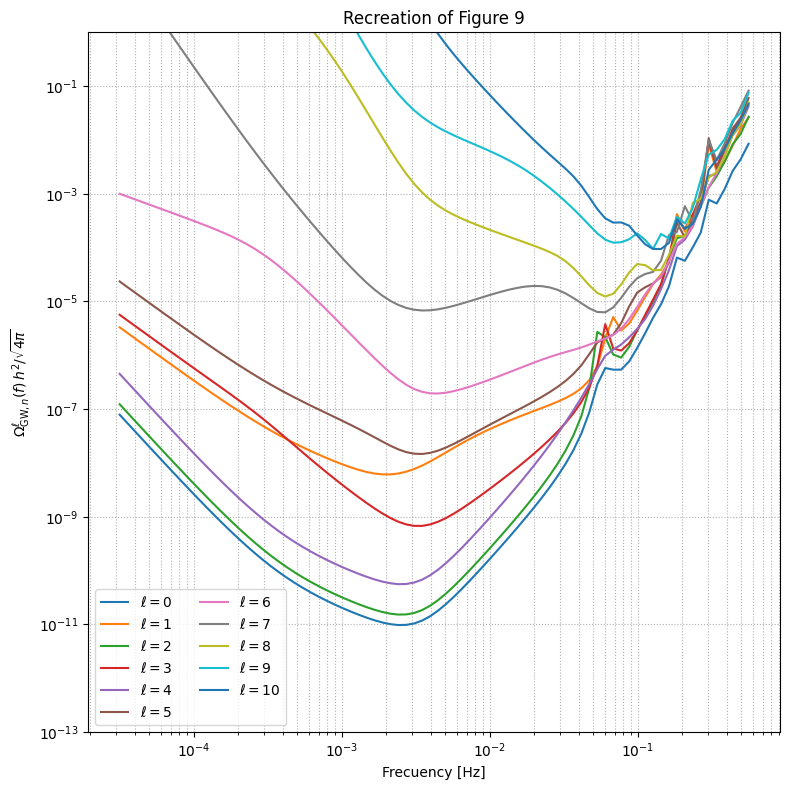

In [145]:
#plotter broertje

f = np.logspace(-4.5, -0.25, 80)
curves = recreate_figure9_clean(f, lmax=10, nside=64, rel_resp_floor=1e-20)

plt.figure(figsize=(8, 8))
for ell in range(0, 11):
    plt.loglog(f, curves[ell], label=fr"$\ell={ell}$")

plt.xlabel("Frecuency [Hz]")
plt.ylim([1e-13, 1e0])
plt.ylabel(r"$\Omega^{\ell}_{{\rm GW},n}(f)\,h^2 / \sqrt{4\pi}$")
plt.title("Recreation of Figure 9")
plt.grid(True, which="both", ls=":")
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

In [146]:
import numpy as np
import pandas as pd

def eq444_snr_table_from_sensitivity(
    f_grid,
    omega_sens_by_ell,   # dict: ell -> omega_sens_ell(f)  (THIS is the sensitivity curve omega)
    OmegaGW_h2,          # function f -> Omega_GW(f) h^2  OR array on f_grid
    Tobs_yr=4.0,
    Cl=None,             # optional multipole weights: dict or array; uses Omega_l = sqrt(C_l)*OmegaGW
):

    f = np.asarray(f_grid, dtype=float)
    if np.any(np.diff(f) <= 0):
        raise ValueError("f_grid must be strictly increasing.")

    # Evaluate Omega_GW(f)h^2 on the same grid
    if callable(OmegaGW_h2):
        OmegaGW_vals = np.asarray(OmegaGW_h2(f), dtype=float)
    else:
        OmegaGW_vals = np.asarray(OmegaGW_h2, dtype=float)
        if OmegaGW_vals.shape != f.shape:
            raise ValueError("If OmegaGW_h2 is an array, it must have the same shape as f_grid.")

    Tobs_sec = float(Tobs_yr * 365.25 * 24.0 * 3600.0)

    rows = []
    for ell in sorted(omega_sens_by_ell.keys()):
        omega_sens = np.asarray(omega_sens_by_ell[ell] * np.sqrt(4*np.pi), dtype=float)

        # optional multipole scaling: Omega_lGW = sqrt(C_l) * Omega_GW
        if Cl is None:
            C_l = 1.0
        elif isinstance(Cl, dict):
            C_l = float(Cl.get(ell, 0.0))
        else:
            C_l = float(Cl[ell])

        Omega_lGW = np.sqrt(max(C_l, 0.0)) * OmegaGW_vals

        # Mask out thresholded / invalid parts (your code uses inf when below threshold)
        mask = np.isfinite(omega_sens) & (omega_sens > 0) & np.isfinite(Omega_lGW)
        if np.count_nonzero(mask) < 2:
            snr2 = 0.0
        else:
            integrand = (Omega_lGW[mask] / omega_sens[mask])**2
            snr2 = float(Tobs_sec * np.trapz(integrand, f[mask]))

        rows.append({"ell": ell, "snr2": snr2, "snr": np.sqrt(snr2)})

    df = pd.DataFrame(rows).set_index("ell")
    return df


# -------------------------
# Use with YOUR existing code
# -------------------------
# 1) build sensitivity curves (your omega_ell dict)
omega_ell = curves

# 2) define a signal spectrum Omega_GW(f)h^2 (example: flat)
Omega0 = 1e-12
OmegaGW_h2 = lambda f: Omega0 * np.ones_like(f)

# 3) compute table
df = eq444_snr_table_from_sensitivity(
    f_grid=f,
    omega_sens_by_ell=omega_ell,   # <-- sensitivity curves used as omega
    OmegaGW_h2=OmegaGW_h2,
    Tobs_yr=4.0,
)
display(df)

,snr2,snr
ell,,
0,2.919570e+02,17.086749
1,7.841380e-04,0.028002
2,1.189795e+02,10.907772
3,7.934543e-02,0.281683
4,8.822020e+00,2.970189
5,1.977975e-04,0.014064
6,2.046051e-06,0.001430
7,1.047487e-08,0.000102
8,2.242640e-09,0.000047
